<a href="https://colab.research.google.com/github/saraashraf29/AI-vs-Human-Text-Detector---Machine-Learning-Pipeline/blob/main/ProjectNLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
import nltk
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.pipeline import Pipeline



In [12]:
try:
    df = pd.read_csv('/content/AI_Human.csv', engine='python', on_bad_lines='skip')

    print(f"Total rows loaded: {df.shape[0]}\n")

    display(df.head())

    print("\nDataset Info:")
    df.info()

    duplicates = df.duplicated().sum()
    print(f"\nTotal Duplicates: {duplicates}")

except Exception as e:
    print(f"An error occurred: {e}")

Total rows loaded: 24996



,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24996 entries, 0 to 24995
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   text       24996 non-null  object 
 1   generated  24996 non-null  float64
dtypes: float64(1), object(1)
memory usage: 390.7+ KB

Total Duplicates: 0


In [14]:

# ---------------------------------------------------------
# Step 2: Prepare the text and Split the data
# ---------------------------------------------------------
# We use the RAW text directly. The Pipeline will handle basic cleaning.
X = df['text']
y = df['generated']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}\n")

Training data shape: (19996,)
Testing data shape: (5000,)



In [15]:
# ---------------------------------------------------------
# Step 3, 4 & 6: Create, Train, and Prepare to Save the Pipeline
# ---------------------------------------------------------
print("Step 3 & 4: Building and Training the Pipeline")
print("This creates TF-IDF features and trains the Logistic Regression model together...")

# We combine TF-IDF and Logistic Regression into one single Pipeline object
# TfidfVectorizer automatically converts text to lowercase and removes basic punctuation
pipeline = Pipeline([
    ('vectorizer', TfidfVectorizer(max_features=50000, ngram_range=(1, 2))),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train the ENTIRE pipeline at once using the raw text
pipeline.fit(X_train, y_train)
print("Pipeline training complete!\n")

Step 3 & 4: Building and Training the Pipeline
This creates TF-IDF features and trains the Logistic Regression model together...
Pipeline training complete!



--- Step 5: Evaluating the Model ---
Model Accuracy: 98.76%

--- Classification Report ---
              precision    recall  f1-score   support

   Human (0)       0.98      1.00      0.99      3222
      AI (1)       0.99      0.97      0.98      1778

    accuracy                           0.99      5000
   macro avg       0.99      0.98      0.99      5000
weighted avg       0.99      0.99      0.99      5000


Generating Confusion Matrix Plot...


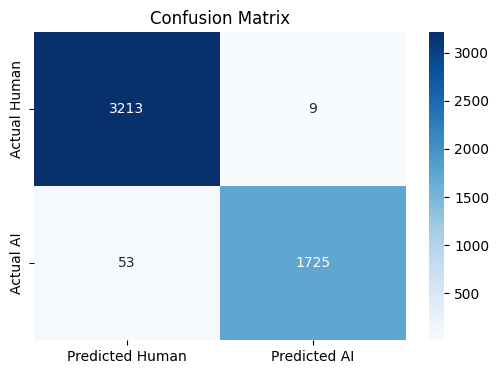

In [16]:
# ---------------------------------------------------------
# Step 5: Evaluate the model
# ---------------------------------------------------------
print("--- Step 5: Evaluating the Model ---")
y_pred = pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Human (0)', 'AI (1)']))

print("\nGenerating Confusion Matrix Plot...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Human', 'Predicted AI'],
            yticklabels=['Actual Human', 'Actual AI'])
plt.title('Confusion Matrix')
plt.show()

In [17]:
# ---------------------------------------------------------
# Step 6: Save the complete trained pipeline
# ---------------------------------------------------------
print("Step 6: Saving the Pipeline")
# We save it with the exact name expected by the professor's main.py
file_name = 'ai_text_classifier.joblib'
joblib.dump(pipeline, file_name)

print(f"Success! The pipeline is saved as '{file_name}'.")
print("Please download this file from the Colab file explorer.")

Step 6: Saving the Pipeline
Success! The pipeline is saved as 'ai_text_classifier.joblib'.
Please download this file from the Colab file explorer.
